README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00006.parquet:   0%|          | 0.00/136M [00:00<?, ?B/s]

data/train-00001-of-00006.parquet:   0%|          | 0.00/142M [00:00<?, ?B/s]

data/train-00002-of-00006.parquet:   0%|          | 0.00/136M [00:00<?, ?B/s]

data/train-00003-of-00006.parquet:   0%|          | 0.00/136M [00:00<?, ?B/s]

...

data/test-00002-of-00003.parquet:   0%|          | 0.00/73.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/901028 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/415416 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/415416 [00:00<?, ? examples/s]

Comptage brut : Counter({False: 358596, True: 56820})


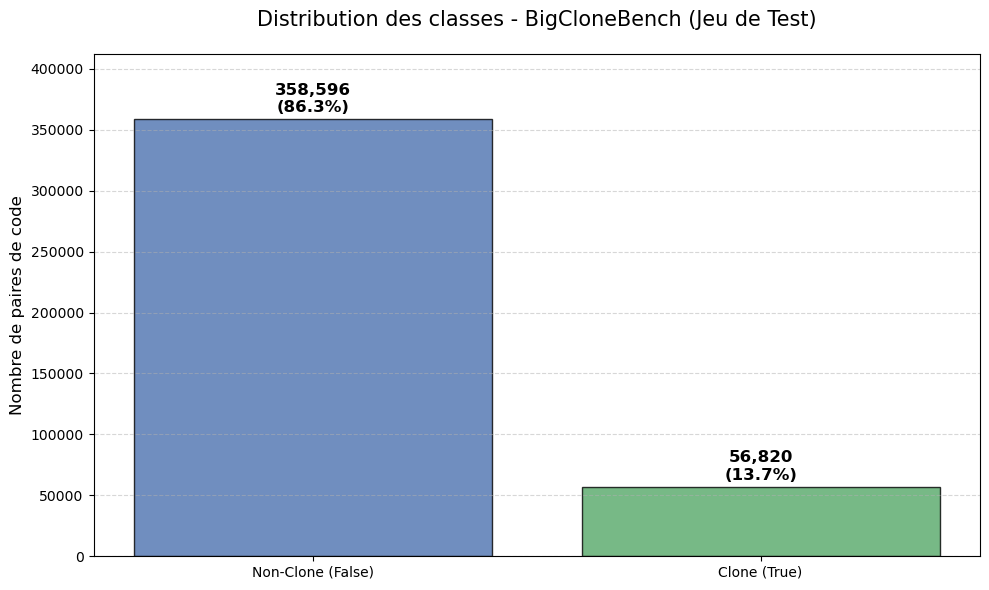

In [1]:
import matplotlib.pyplot as plt
from datasets import load_dataset
import pandas as pd
from collections import Counter

# 1. Chargement du dataset (BigCloneBench)
# Attention : le téléchargement peut être long la première fois (~2-3 Go)
ds = load_dataset("google/code_x_glue_cc_clone_detection_big_clone_bench")

# 2. Extraction des labels du jeu de test
# On convertit en Pandas ou on utilise directement la liste pour compter
# Le dataset contient généralement les colonnes 'id', 'func1', 'func2', 'label'
labels = ds['test']['label']

# 3. Comptage des classes (True = Clone, False = Non-Clone)
counts = Counter(labels)
print(f"Comptage brut : {counts}")

# Préparation des données pour le graphique
categories = ['Non-Clone (False)', 'Clone (True)']
# On s'assure de l'ordre : False (0) puis True (1)
values = [counts[False], counts[True]] 

# 4. Création du graphique
plt.figure(figsize=(10, 6))
bars = plt.bar(categories, values, color=['#4c72b0', '#55a868'], edgecolor='black', alpha=0.8)

# Ajout des titres et labels
plt.title('Distribution des classes - BigCloneBench (Jeu de Test)', fontsize=15, pad=20)
plt.ylabel("Nombre de paires de code", fontsize=12)

# 5. Ajout des annotations (Nombre + Pourcentage)
total = sum(values)
for bar in bars:
    height = bar.get_height()
    percent = (height / total) * 100
    plt.text(bar.get_x() + bar.get_width() / 2, height + (max(values)*0.01), 
             f'{int(height):,}\n({percent:.1f}%)', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# Finitions
plt.ylim(0, max(values) * 1.15) # Marge en haut
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

On constate que les données de nos jeux de données ne sont pas également réparties ; nous devrons prendre cela en compte lors de nos expériences.